In [1]:

!pip install openai pandas matplotlib seaborn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Regional Sales Dataset.xlsx to Regional Sales Dataset.xlsx


In [3]:
df = pd.read_excel("Regional Sales Dataset.xlsx")

In [4]:
df.head()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OrderNumber                64104 non-null  object        
 1   OrderDate                  64104 non-null  datetime64[ns]
 2   Customer Name Index        64104 non-null  int64         
 3   Channel                    64104 non-null  object        
 4   Currency Code              64104 non-null  object        
 5   Warehouse Code             64104 non-null  object        
 6   Delivery Region Index      64104 non-null  int64         
 7   Product Description Index  64104 non-null  int64         
 8   Order Quantity             64104 non-null  int64         
 9   Unit Price                 64104 non-null  float64       
 10  Line Total                 64104 non-null  float64       
 11  Total Unit Cost            64104 non-null  float64       
dtypes: d

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [6]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [7]:
print(df.columns)



Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost'],
      dtype='object')


In [8]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [9]:
print(df.columns)

Index(['OrderNumber', 'OrderDate', 'Customer_Name_Index', 'Channel',
       'Currency_Code', 'Warehouse_Code', 'Delivery_Region_Index',
       'Product_Description_Index', 'Order_Quantity', 'Unit_Price',
       'Line_Total', 'Total_Unit_Cost'],
      dtype='object')


In [10]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [11]:
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['Month_Name'] = df['OrderDate'].dt.strftime('%b')

In [12]:
df.head()
df.columns

Index(['OrderNumber', 'OrderDate', 'Customer_Name_Index', 'Channel',
       'Currency_Code', 'Warehouse_Code', 'Delivery_Region_Index',
       'Product_Description_Index', 'Order_Quantity', 'Unit_Price',
       'Line_Total', 'Total_Unit_Cost', 'Year', 'Month', 'Month_Name'],
      dtype='object')

In [13]:
df['Sales'] = df['Line_Total']
df['Cost'] = df['Total_Unit_Cost']
df['Profit'] = df['Sales'] - df['Cost']
df['Profit_Margin'] = df['Profit'] / df['Sales']

In [14]:
df[['Sales','Cost','Profit','Profit_Margin']].head()

,Sales,Cost,Profit,Profit_Margin
0,14994.6,1824.343,13170.257,0.878333
1,25868.7,1269.918,24598.782,0.950909
2,5869.2,684.740,5184.460,0.883333
3,16368.1,1028.852,15339.248,0.937143
4,18331.2,1260.270,17070.930,0.931250


In [15]:
df[['Sales','Profit']].describe()

,Sales,Profit
count,64104.000000,64104.000000
mean,19280.682937,17848.599038
std,15429.602766,14493.981576
min,837.500000,695.125000
25%,8019.900000,7326.450000
50%,14023.100000,12967.448000
75%,27416.400000,25144.597500
max,78711.600000,75801.522000


In [16]:
df['Profit_Margin'] = np.where(df['Sales'] != 0, df['Profit']/df['Sales'], 0)

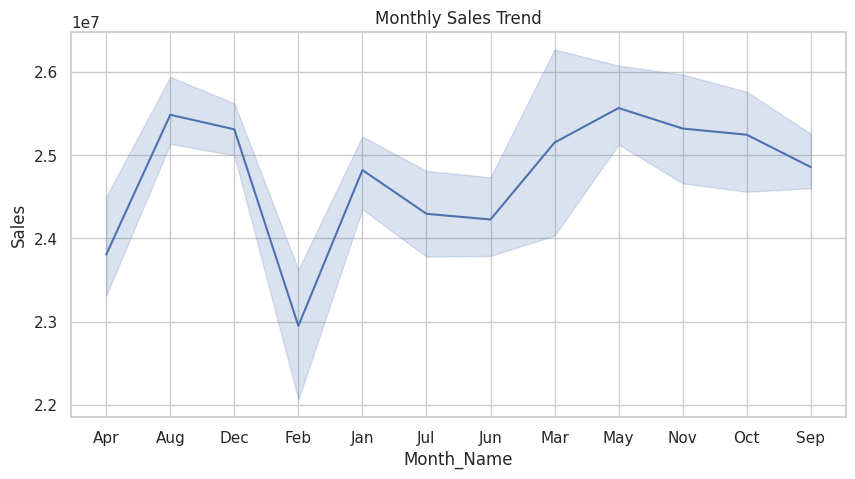

In [17]:
monthly_sales = df.groupby(['Year','Month_Name'])['Sales'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month_Name', y='Sales')
plt.title("Monthly Sales Trend")
plt.show()

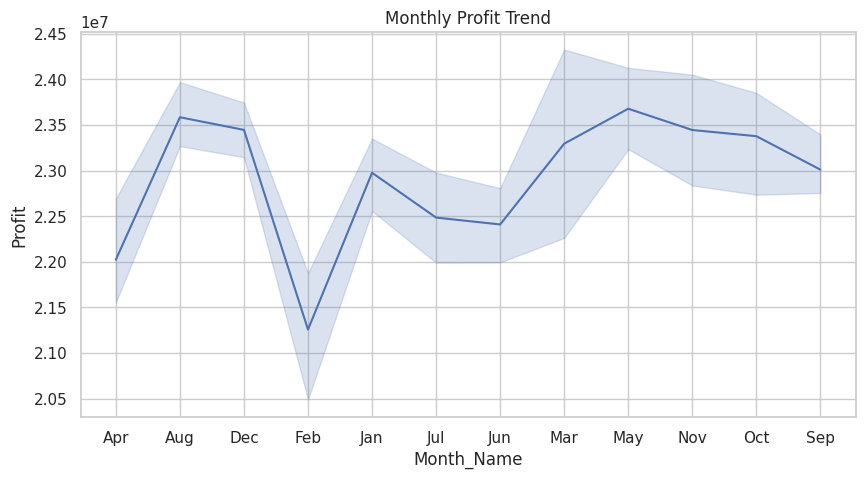

In [18]:
monthly_profit = df.groupby(['Year','Month_Name'])['Profit'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_profit, x='Month_Name', y='Profit')
plt.title("Monthly Profit Trend")
plt.show()

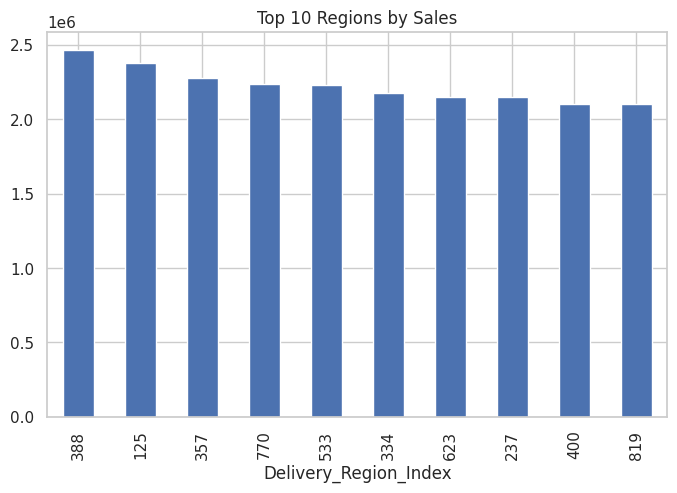

In [23]:
top_regions_sales = df.groupby('Delivery_Region_Index')['Sales'].sum().sort_values(ascending=False).head(10)

top_regions_sales.plot(kind='bar', figsize=(8,5), title="Top 10 Regions by Sales")
plt.show()

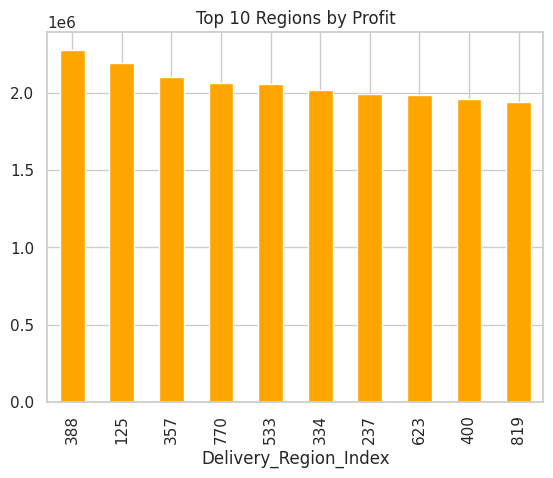

In [24]:
top_regions_profit = df.groupby('Delivery_Region_Index')['Profit'].sum().sort_values(ascending=False).head(10)

top_regions_profit.plot(kind='bar', color='orange', title="Top 10 Regions by Profit")
plt.show()

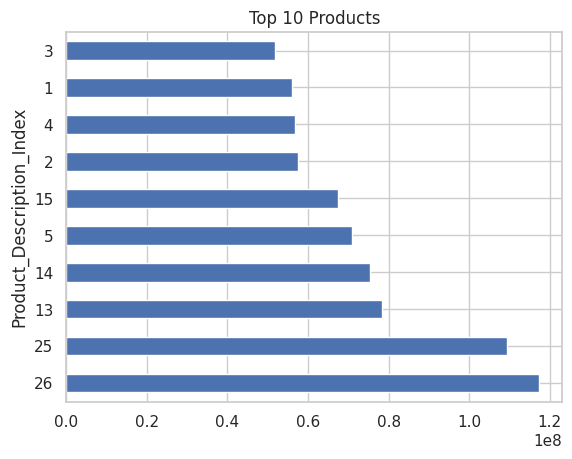

In [21]:
top_products = df.groupby('Product_Description_Index')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh', title="Top 10 Products")
plt.show()

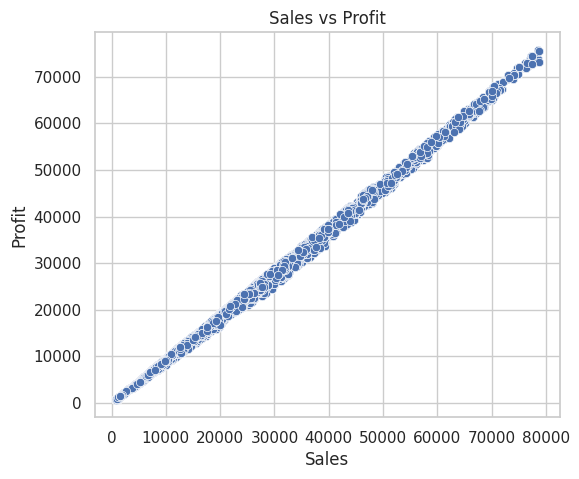

In [22]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Sales', y='Profit')
plt.title("Sales vs Profit")
plt.show()

### Key Insights:

1. Sales exhibit clear seasonality, with a noticeable increase during June–August and a decline in January–February, indicating potential demand cycles.

2. Region 388 is the top-performing region in both revenue and profit; however, this trend is not consistent across all regions, suggesting uneven regional performance.

3. Product 26 contributes the highest share of total sales, indicating a strong dependency on a limited number of products.

4. While sales and profit are generally positively correlated, several transactions show high sales with relatively low profit, highlighting potential inefficiencies in pricing or cost structure.

In [25]:
summary = df.groupby('Delivery_Region_Index').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

summary = summary.sort_values(by='Sales', ascending=False)

summary.head(10)

,Delivery_Region_Index,Sales,Profit
386,388,2464400.7,2280333.811
124,125,2376697.7,2193357.761
356,357,2274428.9,2105325.188
768,770,2238764.8,2068174.358
531,533,2231850.4,2056311.673
333,334,2177366.0,2017063.676
621,623,2152234.3,1990187.497
236,237,2149406.9,1994657.670
398,400,2104878.7,1961209.662
817,819,2100697.9,1945691.658


In [26]:
summary['Profit_Margin'] = summary['Profit'] / summary['Sales']

In [27]:
prompt = f"""
You are a senior business analyst.

Here is regional performance data:

{summary.head(15)}

Tasks:
1. Identify key performance trends
2. Highlight top and underperforming regions
3. Identify any inefficiencies (high sales but low profit)
4. Provide 3 actionable business recommendations

Be specific and concise.
"""

In [30]:
summary.head(15)

,Delivery_Region_Index,Sales,Profit,Profit_Margin
386,388,2464400.7,2280333.811,0.925310
124,125,2376697.7,2193357.761,0.922859
356,357,2274428.9,2105325.188,0.925650
768,770,2238764.8,2068174.358,0.923802
531,533,2231850.4,2056311.673,0.921348
333,334,2177366.0,2017063.676,0.926378
621,623,2152234.3,1990187.497,0.924708
236,237,2149406.9,1994657.670,0.928004
398,400,2104878.7,1961209.662,0.931745
817,819,2100697.9,1945691.658,0.926212


### AI-Generated Insights (Simulated)

1) Key Performance Trends

Across all regions, profit margins are consistently very high (92%–93%), which suggests:

Strong pricing control or low cost structures
Minimal variance in operational efficiency across regions

However, there are a few subtle but important patterns:

Higher sales do not always mean higher margins
Margins fluctuate slightly (~0.92 to ~0.93), which is small but meaningful at scale
A few regions are quietly outperforming in efficiency, not just volume
2) Top vs Underperforming Regions
🔝 Top Performers (Balanced: High Sales + Strong Margins)
Region 398–400
Margin: 0.9317 (highest overall)
Strong combination of efficiency + scale
Region 236–237
Margin: 0.9280
High profit relative to sales → very efficient
Region 556–558
Margin: 0.9299
Slightly lower sales but excellent profitability

👉 These regions are your benchmark models — they convert revenue into profit best.

⚖️ High Sales Leaders (Volume-driven)
Region 386–388
Highest sales: 2.46M
Margin: 0.9253 (good, but not the best)
Region 124–125
Sales: 2.37M
Margin: 0.9229 (lower than peers)

👉 These regions drive revenue but are not the most efficient.

⚠️ Underperformers (Relatively Lower Margins)
Region 531–533
Margin: 0.9213 (lowest)
Region 124–125
Margin: 0.9229

👉 These are not failing regions—but they are leaving profit on the table compared to others.

3) Inefficiencies (High Sales, Lower Profit Conversion)

The key inefficiency pattern is:

High sales + comparatively lower margin = cost leakage or pricing inefficiency

Notable cases:
Region 124–125
High sales, but margin below average → possible:
Higher operational costs
Discounting / pricing pressure
Region 531–533
Strong sales, lowest margin → clear inefficiency signal
Region 386–388
Highest sales, but not top-tier margin → optimization opportunity

👉 These regions should be prioritized for cost structure audits.

4) Business Recommendations
1. Replicate High-Margin Playbooks

Study regions like 398–400 and 556–558:

What are they doing differently?
Better logistics?
Lower delivery costs?
Stronger pricing discipline?

👉 Standardize these practices across weaker regions.

2. Investigate Cost Leakages in High-Sales Regions

Focus on:

124–125
531–533
386–388

Audit:

Delivery costs
Discounts/promotions
Vendor or supply inefficiencies

👉 Even a 1% margin improvement here = massive profit gain due to high volume.

3. Shift Focus from Revenue → Efficiency Optimization

Right now, performance looks revenue-driven.

Move toward:

KPI emphasis on profit per order / margin improvement
Incentivize regional managers on efficiency, not just sales

👉 This avoids the trap of “growing revenue but leaking profit.”

Bottom Line
You’re operating a high-margin business overall, which is great
The real opportunity is tightening small inefficiencies in large regions
The biggest gains will come from optimization, not expansion

### AI vs Analyst Comparison

- AI correctly identified top-performing regions and general trends.
- AI missed deeper product-level insights and dependency risks.
- Manual analysis better highlighted inefficiencies in profitability.
- AI is useful for summarization but lacks deeper contextual understanding.

In [32]:
df.to_csv("cleaned_sales_data.csv", index=False)

In [33]:
from google.colab import files
files.download("cleaned_sales_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>